c:\Users\pawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:12:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 100.00%
Decision Tree Accuracy: 100.00%
Random Forest Accuracy: 100.00%
SVM Accuracy: 68.33%


C:\Users\pawan\AppData\Local\Temp\ipykernel_20036\3548212941.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=scores, palette="viridis")


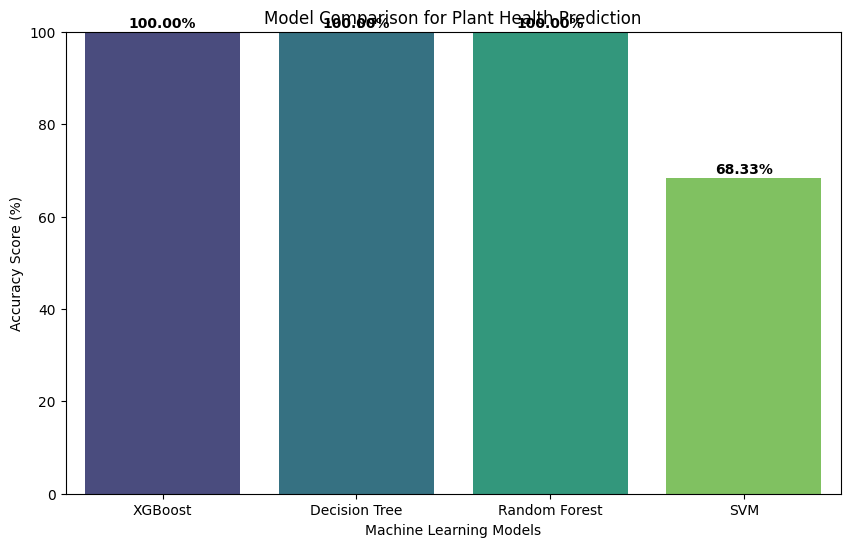


--- Final Comparison Table ---
           Model  Accuracy (%)
0        XGBoost    100.000000
1  Decision Tree    100.000000
2  Random Forest    100.000000
3            SVM     68.333333


In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Models import
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Load and Prepare Data
data = pd.read_csv("plant_data_7params_3000.csv")
X = data[['moisture','temperature','humidity','light','ph','air_quality','nutrient']]
y = data['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 2. Models ki List taiyar karein
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True)
}

# 3. Training aur Accuracy check
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    accuracy_results[name] = acc * 100  # Percentage mein convert kiya
    print(f"{name} Accuracy: {acc*100:.2f}%")

# 4. Visualization (Graph banana)
plt.figure(figsize=(10, 6))
model_names = list(accuracy_results.keys())
scores = list(accuracy_results.values())

sns.barplot(x=model_names, y=scores, palette="viridis")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score (%)")
plt.title("Model Comparison for Plant Health Prediction")
plt.ylim(0, 100) # Graph 0 se 100 tak dikhane ke liye

# Accuracy values graph ke upar likhne ke liye
for i, v in enumerate(scores):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

# 5. Final Comparison Table
df_compare = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy (%)'])
print("\n--- Final Comparison Table ---")
print(df_compare.sort_values(by='Accuracy (%)', ascending=False))